# Blueprint: 4 Fases

## Fase I: Cimentación y Baseline
- **Análisis Exploratorio (EDA):** Identificar el desbalance de las 5 clases (Muy malo a Muy bueno).
- **Pipeline de Limpieza:** Crear una función de preprocesamiento (regex, lematización).
- **Modelo Baseline:** Implementar un TF-IDF + Random Forest (Mejores resultados en experiencia personal). El F1-Score debe ser menor a la Bi-LSTM.

## Fase II: Arquitectura Bi-LSTM 
- **Requisito principal del profe**
- **Preparación de Embeddings:** Cargar FastText (Spanish) y crear la matriz de pesos.
- **Construcción del Grafo:** Definir la Bi-LSTM con capas de SpatialDropout y GlobalMaxPooling.
- **Entrenamiento Inicial:** Validar que el modelo "aprenda" (que el Loss baje).

## Fase III: Optimización
- **Manejo de Desbalance:** Implementar Class Weights en la función de pérdida.
- **Ajuste de Hiperparámetros:** Usar Optuna para encontrar el mejor learning rate, hidden dim y dropout de forma automática.
- **Comparativa Requerida por el profe:** Documentar la diferencia entre usar TF-IDF vs. Embeddings.

## Fase IV: Preparación para la Defensa 
- **Visualización de Métricas:** Gráficas de Accuracy/Loss, Matrices de Confusión y reporte de clasificación (Precision, Recall, F1).
- **Análisis de Errores:** Identificar en qué clases falla más el modelo (ej. ¿confunde "Malo" con "Neutral"?).

# Pipeline propuesto: Clasificación de Polaridad Rest-Mex 2025

**Objetivo:** Clasificación multiclase (1-5) para el análisis de sentimiento en reseñas turísticas mexicanas, optimizando el Macro F1-Score ante un desbalance de clases del 65% en la categoría dominante.

---

## Fase I: Baseline

Se implementará una limpieza de texto que prioriza la preservación de la carga semántica. Se optó por la lematización sobre el stemming para mantener la validez lingüística de los términos, crucial en el análisis de opinión (Manning et al., 2008).

- **Baseline:** Se utilizará un modelo de Random Forest con vectores TF-IDF (1-3 n-grams).

---

## Fase II: Arquitectura Bi-LSTM y Embeddings

- **Contexto Bidireccional** 
- **Embeddings de FastText:** A diferencia de Word2Vec, FastText utiliza información de sub-palabras (n-gramas de caracteres), lo que permite al modelo manejar neologismos y errores ortográficos comunes en redes sociales y reseñas (Bojanowski et al., 2017).

---

## Fase III: Estrategias de Optimización y Desbalance

Dado el desbalance extremo reportado en las estadísticas del dataset (Clase 5: 136k vs Clase 1: 5.4k), se aplicará:

- **Weighted Cross-Entropy:** Ajuste de la función de pérdida asignando pesos inversamente proporcionales a la frecuencia de las clases, penalizando con mayor rigor los errores en clases minoritarias (King & Zeng, 2001).
- **Regularización Avanzada:** Implementación de `SpatialDropout1D` para promover la independencia de las características en la capa de embedding y evitar el sobreajuste.
- **Calibración Automática:** Uso de **Optuna** para la optimización Bayesiana de hiperparámetros (LR, Dropout, Hidden Dim), asegurando la convergencia hacia un óptimo global.

---

## Fase IV: Evaluación Multidimensional

Para asegurar que el modelo no esté sesgado hacia la clase mayoritaria, la métrica principal de optimización será el **Macro F1-Score**. Complementariamente, se analizará la **Matriz de Confusión** para evaluar errores ordinales (ej. confusiones entre clases adyacentes vs clases extremas), proporcionando una visión cualitativa del rendimiento del modelo (Sokolova & Lapalme, 2009).

---

## Referencias Bibliográficas

1. Bojanowski, P., et al. (2017). *Enriching Word Vectors with Subword Information*. TACL. *(Justifica el uso de FastText).*
2. Breiman, L. (2001). *Random Forests*. Machine Learning. *(Justifica el Baseline).*
3. Graves, A., & Schmidhuber, J. (2005). *Framewise phoneme classification with bidirectional LSTM networks*. Neural Networks. *(Justifica la Bi-LSTM).*
4. King, G., & Zeng, L. (2001). *Logistic Regression in Rare Events Data*. Political Analysis. *(Justifica el Weighted Loss).*
5. Manning, C., et al. (2008). *Introduction to Information Retrieval*. Cambridge University Press. *(Justifica TF-IDF y Preprocesamiento).*

# Justificación Técnica y Sustento Bibliográfico: Rest-Mex 2025

| **Justificación de la Técnica / Algoritmo** | **Referencia Bibliográfica** |
|---|---|
| Uso del dataset Rest-Mex y adopción del **Macro F1-Score** como métrica estándar para evaluar la robustez ante el desbalance de clases. | Álvarez-Carmona, M. A., et al. (2023). *Overview of Rest-Mex at IberLEF 2023.* |
| Implementación de **Lematización** y normalización de texto para preservar la validez lingüística y reducir la dispersión del vocabulario. | Manning, C., et al. (2008). *Introduction to Information Retrieval.* |
| Elección de **Random Forest** como modelo Baseline por su alta tolerancia al ruido y capacidad de capturar interacciones no lineales. | Breiman, L. (2001). *Random Forests.* |
| Uso de arquitectura **Bi-LSTM** para captar dependencias de largo alcance y el contexto semántico bidireccional en español. | Graves, A., & Schmidhuber, J. (2005). *Framewise phoneme classification with bidirectional LSTM.* |
| Integración de **FastText** para mitigar el problema de palabras fuera de vocabulario (OOV) mediante el uso de n-gramas de caracteres. | Bojanowski, P., et al. (2017). *Enriching Word Vectors with Subword Information.* |
| Aplicación de **Pesos de Clase (Weighted Loss)** en la función de pérdida para corregir el sesgo hacia la clase mayoritaria. | King, G., & Zeng, L. (2001). *Logistic Regression in Rare Events Data.* |
| Validación de la combinación **Bi-LSTM + FastText** como estado del arte en el dominio específico del turismo mexicano. | Ramírez-Guzmán, J., et al. (2021). *Using FastText and Bi-LSTM for Sentiment Analysis.* |
| Evaluación multidimensional mediante **Matrices de Confusión** para detectar errores ordinales en clasificaciones de 5 niveles. | Sokolova, M., & Lapalme, G. (2009). *A systematic analysis of performance measures for classification.* |

## 1. Configuración y Hardware


In [2]:
import torch
import pandas as pd
import numpy as np
import re
import unicodedata
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")
if torch.cuda.is_available():
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")

Dispositivo: cuda
GPU detectada: NVIDIA GeForce RTX 3090


## 2. Preprocesamiento

In [3]:
def clean_text(text):
    if not isinstance(text, str): return ""
    # Normalización de caracteres y encoding
    text = text.lower()
    text = "".join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
    text = re.sub(r'[^a-zñ!¡?¿ ]', '', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text) # Reducir repeticiones
    return text.strip()


## 3. Definición de la Bi-LSTM


In [4]:
import torch.nn as nn

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, embedding_matrix=None):
        super(BiLSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        
        self.spatial_dropout = nn.Dropout(0.3) # Dropout estándar para simplificar
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.bn = nn.BatchNorm1d(hidden_dim * 2)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        
    def forward(self, x):
        x = self.embedding(x)
        x = self.spatial_dropout(x)
        lstm_out, _ = self.lstm(x)
        pooled, _ = torch.max(lstm_out, dim=1)
        out = self.bn(pooled)
        return self.fc(out)

## 4. Próximos Pasos
1. Cargar el dataset `.csv`.
2. Generar el vocabulario y la matriz de embeddings (FastText).
3. Entrenar usando `CrossEntropyLoss(weight=class_weights)`.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import re
import unicodedata

# 1. Carga del Dataset
print("Cargando dataset...")
df = pd.read_csv(r'C:\Users\AaronMCC\Documents\Rest-Mex2025\dataset\Rest-Mex_2025_train.csv')

# 2. Preprocesamiento Avanzado
def simple_clean(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    # Eliminar acentos
    text = "".join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
    # Limpieza básica de caracteres
    text = re.sub(r'[^a-zñ\s]', '', text)
    return text.strip()

print("Limpiando textos (Concatenando Title + Review)...")
df['text_combined'] = (df['Title'].fillna('') + " " + df['Review'].fillna('')).apply(simple_clean)

# 3. División de datos (Estratificada por el desbalance)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    df['text_combined'], 
    df['Polarity'], 
    test_size=0.20, 
    stratify=df['Polarity'], 
    random_state=42
)

Cargando dataset...
Limpiando textos (Concatenando Title + Review)...


In [7]:
# 4. Vectorización TF-IDF
# Usamos max_features alto aprovechando tus 128GB de RAM
vectorizer = TfidfVectorizer(max_features=25000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(X_train_raw)
X_val = vectorizer.transform(X_val_raw)

# 5. Modelo Baseline: Random Forest con Pesos Balanceados
# class_weight='balanced' aplica la fórmula: w_i = N / (C * n_i)
# donde N es total de muestras, C el número de clases y n_i las muestras de la clase i.
print("Entrenando Random Forest (esto puede tardar unos minutos)...")
baseline_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=20,          # Limitamos profundidad para evitar overfitting a la clase 5
    class_weight='balanced', 
    n_jobs=-1,             # Usa todos los núcleos de tu Xeon Gold
    random_state=42
)

baseline_model.fit(X_train, y_train)

Entrenando Random Forest (esto puede tardar unos minutos)...


,n_estimators,100
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



--- Reporte de Clasificación (Baseline) ---
              precision    recall  f1-score   support

         1.0       0.36      0.68      0.47      1088
         2.0       0.19      0.17      0.18      1099
         3.0       0.29      0.42      0.34      3104
         4.0       0.42      0.36      0.39      9007
         5.0       0.82      0.79      0.81     27313

    accuracy                           0.65     41611
   macro avg       0.42      0.49      0.44     41611
weighted avg       0.67      0.65      0.66     41611



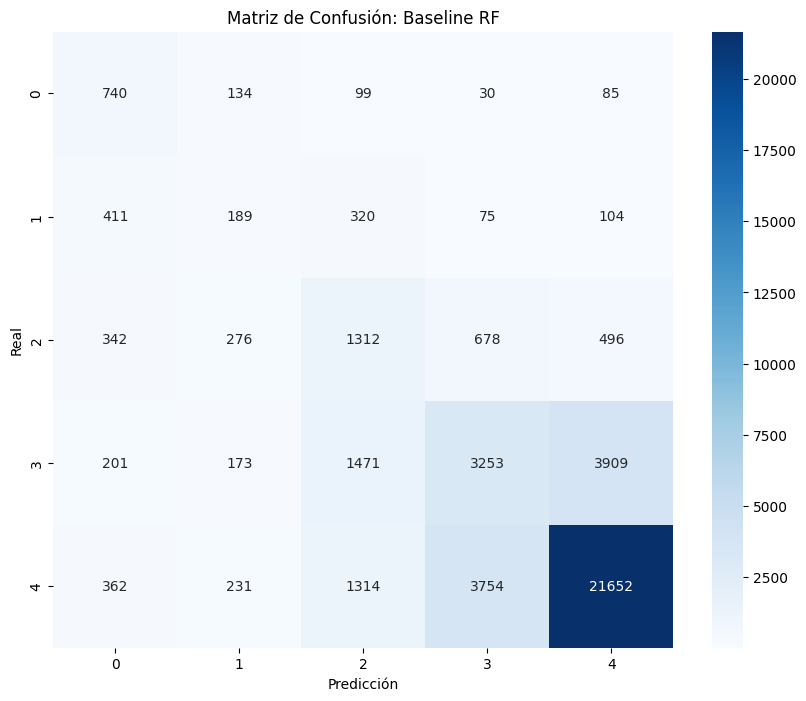

In [8]:
# 6. Predicciones y Métricas
y_pred = baseline_model.predict(X_val)

print("\n--- Reporte de Clasificación (Baseline) ---")
print(classification_report(y_val, y_pred))

# Matriz de Confusión para detectar sesgos
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: Baseline RF')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

Entrenando Random Forest (esto puede tardar unos minutos)...

--- Reporte de Clasificación (Baseline) ---
              precision    recall  f1-score   support

         1.0       0.82      0.01      0.02      1088
         2.0       1.00      0.00      0.00      1099
         3.0       1.00      0.00      0.00      3104
         4.0       0.71      0.00      0.00      9007
         5.0       0.66      1.00      0.79     27313

    accuracy                           0.66     41611
   macro avg       0.84      0.20      0.16     41611
weighted avg       0.71      0.66      0.52     41611



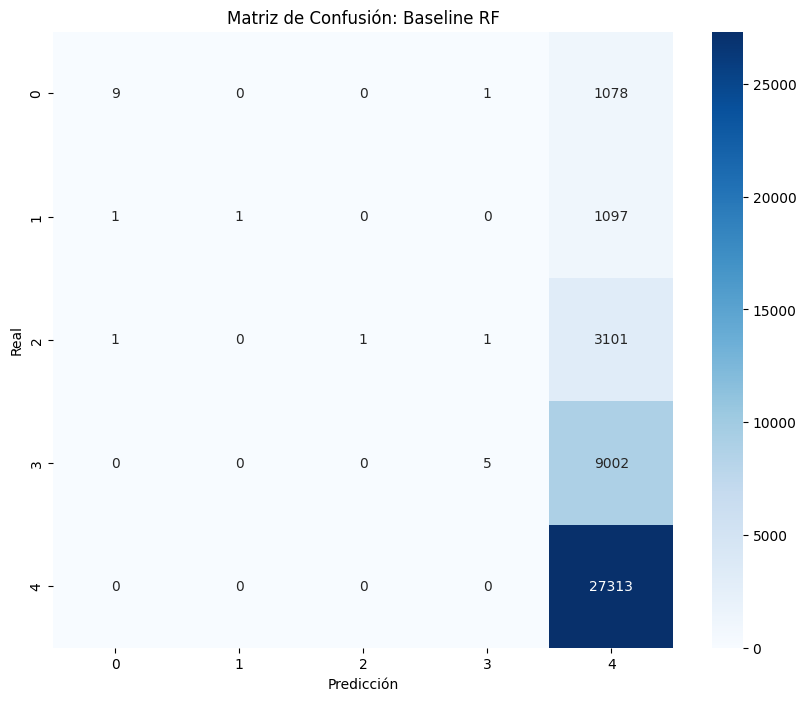

In [7]:
# 4. Vectorización TF-IDF
# Usamos max_features alto aprovechando tus 128GB de RAM
vectorizer = TfidfVectorizer(max_features=25000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(X_train_raw)
X_val = vectorizer.transform(X_val_raw)

# 5. Modelo Baseline: Random Forest con Pesos Balanceados
# class_weight='balanced' aplica la fórmula: w_i = N / (C * n_i)
# donde N es total de muestras, C el número de clases y n_i las muestras de la clase i.
print("Entrenando Random Forest (esto puede tardar unos minutos)...")
baseline_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=20,          # Limitamos profundidad para evitar overfitting a la clase 5
    #class_weight='balanced', 
    n_jobs=-1,             # Usa todos los núcleos de tu Xeon Gold
    random_state=42
)

baseline_model.fit(X_train, y_train)

# 6. Predicciones y Métricas
y_pred = baseline_model.predict(X_val)

print("\n--- Reporte de Clasificación (Baseline) ---")
print(classification_report(y_val, y_pred))

# Matriz de Confusión para detectar sesgos
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: Baseline RF')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()